In [3]:
import jax
import jax.numpy as jnp
import numpy as np
from flax.training.train_state import TrainState
import optax
import gymnax
from wrappers import NormalizeObservationWrapper, NormalizeRewardWrapper
from gymnax.wrappers.purerl import FlattenObservationWrapper, LogWrapper
import wandb
from networks import ActorCritic
from utils import Transition

# PPO
config = {
    "ENV_NAME": "MountainCar-v0",
    "LR": 5e-4,
    "LR_END": 5e-5,
    "NUM_ENVS": 32,
    "NUM_STEPS": 128,
    "TOTAL_TIMESTEPS": 250000,
    "NUM_EPOCHS": 4, # a lot -force memorization
    "MINIBATCH_SIZE": 256,
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.6,
    "CLIP_EPS": 0.2,
    "VF_CLIP": 0.5,
    "ENT_COEF": 0.003,
    "VF_COEF": 0.5,
    "MAX_GRAD_NORM": 0.5,
    "ACTIVATION": "relu",
    "NORMALIZE_REWARDS": True,
    "NORMALIZE_OBS": True,
    "SEED": 42,
    "WARMUP": 128, # warmup steps for running mean/std
    "N_SEEDS": 4,
}

def make_train(config):
    
    batch_size = config["NUM_STEPS"] * config["NUM_ENVS"]
    config["NUM_MINIBATCHES"] = batch_size // config["MINIBATCH_SIZE"] # per epoch
    config["NUM_UPDATES"] = config["TOTAL_TIMESTEPS"] // batch_size
    total_grad_steps = config["NUM_UPDATES"] * config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"]
    
    env, env_params = gymnax.make(config["ENV_NAME"])
    env, env_params = gymnax.make(config["ENV_NAME"])
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)                 # Log REAL returns
    if config["NORMALIZE_REWARDS"]:
        env = NormalizeRewardWrapper(env, gamma=config["GAMMA"]) # Normalize Rewards
    if config["NORMALIZE_OBS"]:
        env = NormalizeObservationWrapper(env) # Normalize Obs
    
    n_actions = env.action_space(env_params).n

    def train(rng):
        network = ActorCritic(env.action_space(env_params).n, activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(env.observation_space(env_params).shape)
        network_params = network.init(_rng, init_x)
        
        lr_scheduler = optax.linear_schedule(
            init_value=config["LR"],
            end_value=config["LR_END"],
            transition_steps=total_grad_steps
        )
        tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adamw(lr_scheduler, eps=1e-5),
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # WARMUP:
        def _warmup_step(runner_state, unused):
            env_state, last_obs, rng = runner_state
            
            # Select RANDOM actions (no need for network here, just exploring state space)
            rng, _rng = jax.random.split(rng)
            rng_action = jax.random.split(_rng, config["NUM_ENVS"])
            action = jax.vmap(env.action_space(env_params).sample)(rng_action)
            
            # Step env (wrappers will update their internal mean/std stats automatically)
            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, config["NUM_ENVS"])
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            
            return (env_state, obsv, rng), None

        # Run the warmup
        warmup_runner_state = (env_state, obsv, rng)
        (env_state, obsv, rng), _ = jax.lax.scan(
            _warmup_step, warmup_runner_state, None, config["WARMUP"]
        )
        # -------------------------

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(env_scan_state, unused):
                train_state, env_state, last_obs, rng= env_scan_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                transition = Transition(
                    done, action, value, reward, log_prob, last_obs, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition
            
            train_state, env_state, last_obs, rng, idx = runner_state
            env_step_state = (train_state, env_state, last_obs, rng)
            (train_state, env_state, last_obs, rng), traj_batch = jax.lax.scan(
                _env_step, env_step_state , None, config["NUM_STEPS"]
            )
            
            # CALCULATE ADVANTAGE
            
            _, last_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            advantages, targets = _calculate_gae(traj_batch, last_val)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                def _update_minbatch(train_state, batch_info):
                    traj_batch, advantages, targets = batch_info

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)

                        # CALCULATE VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["VF_CLIP"], config["VF_CLIP"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - config["ENT_COEF"] * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    total_loss, grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    return train_state, total_loss

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                train_state, total_loss = jax.lax.scan(
                    _update_minbatch, train_state, minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss

            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["NUM_EPOCHS"]
            )
            train_state, _, _, _, rng = update_state
            metric = {k: v.mean() for k, v in traj_batch.info.items()} # performance
            runner_state = (train_state, env_state, last_obs, rng, idx+1)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng, 0)
        runner_state, metrics = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metrics}

    return train

In [4]:
import time
import matplotlib.pyplot as plt
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, 8)
train_vjit = jax.jit(jax.vmap(make_train(config)))
t0 = time.time()
outs = jax.block_until_ready(train_vjit(rngs))
print(f"time: {time.time() - t0:.2f} s")

/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


time: 21.94 s


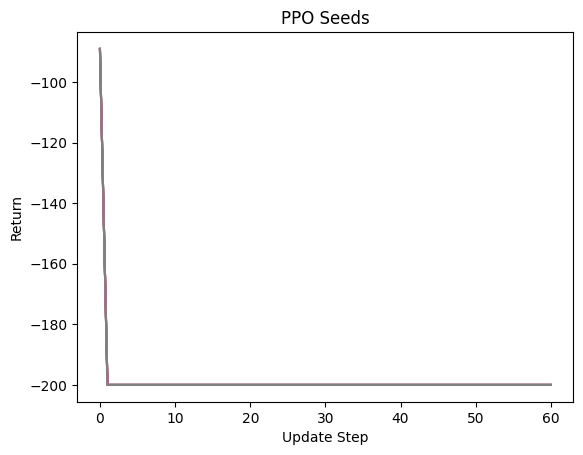

In [5]:
import time
import matplotlib.pyplot as plt
for i in range(8):
    plt.plot(outs["metrics"]["returned_episode_returns"][i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title('PPO Seeds')
plt.savefig('PPO (Normalized Reward).pdf', bbox_inches='tight')
plt.show()